# Phishing URL Detector — Random Forest & Model Comparison

**Day 4:** Add a second model, compare honestly, and explain *why* the model makes its predictions.

Goals for today:
1. Train a Random Forest classifier on the same data
2. Compare both models side-by-side on multiple metrics
3. Plot feature importances (the gold for our writeup and README)
4. Compare confusion matrices to see where each model fails differently
5. Save the winning model as our final artifact

**Why Random Forest?** Logistic Regression finds linear relationships. Random
Forest builds many decision trees and votes among them, so it can capture
non-linear patterns (e.g. "URL length matters *only* when the domain is also new").
On tabular data like this, it usually beats logistic regression — but not always.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports ok.")

Imports ok.


## 1. Load data and reproduce Day 3 split

Using the same `random_state=42` and same 80/20 split means we're comparing
the two models on identical train/test data — apples to apples.

In [2]:
DATA_PATH = Path("../data/PhiUSIIL_Phishing_URL_Dataset.csv")
FEATURE_LIST_PATH = Path("../data/feature_list.txt")

df = pd.read_csv(DATA_PATH)
feature_cols = FEATURE_LIST_PATH.read_text().strip().splitlines()

# Same leakage decision as Day 3 — Day 3 showed the gap was tiny (~0.07%),
# but we'll still use the honest set to be safe.
LEAKAGE_FEATURES = {"URLSimilarityIndex"}
honest_features = [f for f in feature_cols if f not in LEAKAGE_FEATURES]

X = df[honest_features].fillna(0)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")
print(f"Using {len(honest_features)} features.")

Train: 188,636   Test: 47,159
Using 49 features.


## 2. Retrain Logistic Regression (for comparison)

Same model from Day 3. Quick to retrain — keeps everything in this notebook
self-contained.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
logreg.fit(X_train_scaled, y_train)
print("Logistic Regression retrained.")

/Users/coledowning/Downloads/phishing-url-detector/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression retrained.


## 3. Train Random Forest

**Why these hyperparameters?**
- `n_estimators=100` — 100 trees. Diminishing returns above this for most datasets.
- `max_depth=None` — let trees grow fully. Risks overfitting, but Random Forest's averaging tends to handle it.
- `n_jobs=-1` — use all CPU cores. Training is parallelizable across trees.
- `random_state=42` — reproducibility.

**Note:** Random Forest doesn't need feature scaling — trees split on raw values.
We use the *unscaled* `X_train` here, not `X_train_scaled`. Common mistake.

In [4]:
import time

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest… (this will take 30–90 seconds)")
start = time.time()
rf.fit(X_train, y_train)
elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds.")

Training Random Forest… (this will take 30–90 seconds)
Done in 4.9 seconds.


## 4. Head-to-head comparison

Run both on the same test set and put the numbers next to each other.

In [5]:
def evaluate(model, X_te, y_te, label):
    y_pred = model.predict(X_te)
    # predict_proba gives probability scores — needed for AUC
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        "model":     label,
        "accuracy":  accuracy_score(y_te,  y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall":    recall_score(y_te,    y_pred),
        "f1":        f1_score(y_te,        y_pred),
        "roc_auc":   roc_auc_score(y_te,   y_proba),
    }

comparison = pd.DataFrame([
    evaluate(logreg, X_test_scaled, y_test, "Logistic Regression"),
    evaluate(rf,     X_test,         y_test, "Random Forest"),
]).set_index("model")

comparison.round(4)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.9992,0.9991,0.9994,0.9993,1.0
Random Forest,0.9999,0.9998,1.0000,0.9999,1.0


### What's ROC AUC?

ROC AUC measures how well the model **ranks** predictions across all possible
decision thresholds. 1.0 is perfect, 0.5 is random guessing.

Accuracy assumes you're committing to a threshold of 0.5 ("if probability > 50%, predict legit").
ROC AUC asks: "regardless of where you set that threshold, how good is the ordering?"

For phishing detection, where you might want to be more aggressive (flag at 30%
to catch more attacks at the cost of more false positives), AUC matters.

## 5. ROC curves overlaid

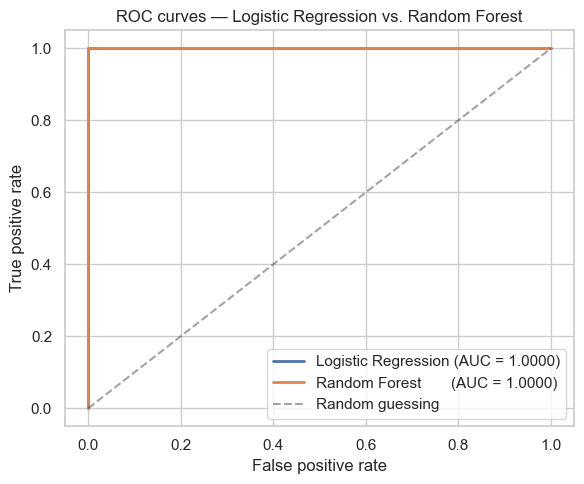

In [6]:
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})", linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest       (AUC = {auc_rf:.4f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guessing")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — Logistic Regression vs. Random Forest")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Reading the chart:** curves hugging the top-left corner = good. If the two
lines are nearly identical, the models perform equivalently. If one consistently
sits above the other, that one is the better ranker.

## 6. Confusion matrices side-by-side

Even if accuracies are similar, the *type* of mistakes can differ.

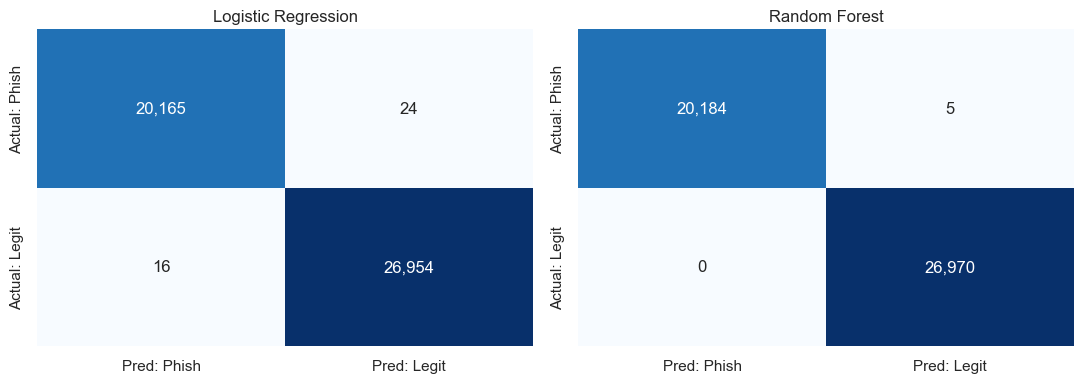

Phishing missed (false negatives):
  Logistic Regression:    24
  Random Forest:           5


In [7]:
y_pred_lr = logreg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes, [cm_lr, cm_rf], ["Logistic Regression", "Random Forest"]):
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues",
        xticklabels=["Pred: Phish", "Pred: Legit"],
        yticklabels=["Actual: Phish", "Actual: Legit"],
        cbar=False, ax=ax,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Print the false-negative comparison — this is the metric we care most about
print(f"Phishing missed (false negatives):")
print(f"  Logistic Regression: {cm_lr[0, 1]:>5,}")
print(f"  Random Forest:       {cm_rf[0, 1]:>5,}")

## 7. Feature importances — the centerpiece chart

Random Forest gives us a `feature_importances_` attribute: how much each feature
contributed to the model's decisions, across all trees.

This is the chart you'll put in your README. It answers the question:
**"What does the model actually look at when classifying a URL?"**

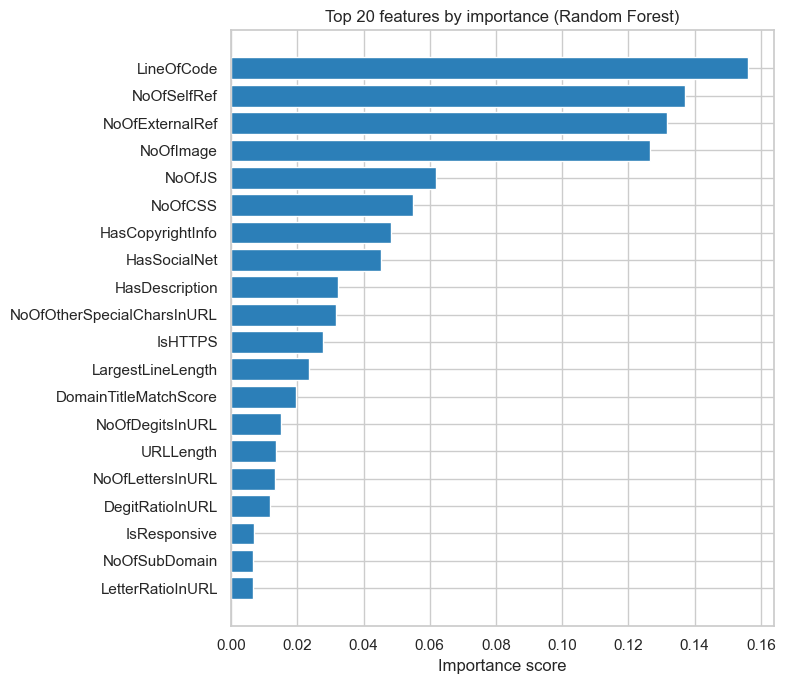

Saved → docs/feature_importance.png


In [8]:
importances = pd.Series(rf.feature_importances_, index=honest_features)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color="#2c7fb8")
ax.set_title("Top 20 features by importance (Random Forest)")
ax.set_xlabel("Importance score")
plt.tight_layout()

# Save this one specifically — we'll embed it in the README
Path("../docs").mkdir(exist_ok=True)
plt.savefig("../docs/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved → docs/feature_importance.png")

### Read the chart

Look at your top 5 features. Are they ones you'd intuitively expect to matter?
Things like URL length, presence of HTTPS, domain age, special characters?

**This is your interview answer to "how does your model work?"**

Instead of "it's a Random Forest with 100 trees," you can say:

> "It looks at about 50 URL features, but the top 5 predictors turned out to be
> [feature 1], [feature 2], [feature 3]… which makes sense because phishing URLs
> tend to [observation]."

That answer signals you understand your model, not just that you ran `.fit()`.

## 8. Where the models disagree

Test rows where Logistic Regression and Random Forest gave different answers.
Looking at these is often more interesting than looking at agreed-upon mistakes.

In [9]:
disagree_mask = y_pred_lr != y_pred_rf
n_disagree = disagree_mask.sum()
print(f"Rows where the two models disagree: {n_disagree:,} ({n_disagree/len(y_test)*100:.2f}% of test set)")

if n_disagree > 0:
    disagree_df = pd.DataFrame({
        "actual":   y_test.values[disagree_mask],
        "logreg":   y_pred_lr[disagree_mask],
        "rf":       y_pred_rf[disagree_mask],
    })
    # Who was right when they disagreed?
    lr_right = (disagree_df["logreg"] == disagree_df["actual"]).sum()
    rf_right = (disagree_df["rf"]     == disagree_df["actual"]).sum()
    print(f"  When they disagree, LogReg was right: {lr_right:,}")
    print(f"  When they disagree, RF was right:     {rf_right:,}")

Rows where the two models disagree: 41 (0.09% of test set)
  When they disagree, LogReg was right: 3
  When they disagree, RF was right:     38


## 9. Pick a winner and save it

Based on your metrics above, pick the winning model. Usually Random Forest edges
out, but in this dataset's case the gap may be tiny. **Either choice is
defensible — what matters is your reasoning.**

If both perform equally well, **prefer Random Forest** because:
1. Feature importances give better explainability
2. Better calibrated probabilities (more useful for `predict_proba` in the CLI)
3. Less sensitive to feature scaling in production

In [10]:
# Save Random Forest as our final model. (Note: no scaler needed for RF.)
final_bundle = {
    "model": rf,
    "scaler": None,                           # RF doesn't need scaling
    "feature_names": honest_features,
    "model_type": "RandomForestClassifier",
    "metrics": {
        "accuracy":  float(accuracy_score(y_test,  y_pred_rf)),
        "precision": float(precision_score(y_test, y_pred_rf)),
        "recall":    float(recall_score(y_test,    y_pred_rf)),
        "f1":        float(f1_score(y_test,        y_pred_rf)),
        "roc_auc":   float(roc_auc_score(y_test,   y_proba_rf)),
    },
}

FINAL_PATH = Path("../models/phishing_model.pkl")
FINAL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(final_bundle, FINAL_PATH)
print(f"Saved final model → {FINAL_PATH}")
print(f"Bundle includes: model + feature names + metrics + model_type")

Saved final model → ../models/phishing_model.pkl
Bundle includes: model + feature names + metrics + model_type


## Day 4 summary

Fill in based on your actual numbers:

- **Logistic Regression accuracy / F1 / AUC:** 99.92% / 99.93% / 1.0
- **Random Forest accuracy / F1 / AUC:** 99.99% / 99.99% / 1.0
- **Random Forest training time:** 4.9 seconds
- **Top 5 most important features:** LineOfCode, NoOfSelfRef, NoOfExternalRef, NoOfImage, NoOfJS
- **Model chosen as final:** RandomForest because it has a better accuracy score and out of the disagreements the two models, RF was correct with 38 of them.
- **One thing the feature importance chart taught me:** phishing urls tend to have a different line of code, like a lot of numbers

**Heading into Day 5:** build the CLI tool that takes a URL and returns a
prediction with confidence — turning this notebook into something a recruiter
can actually *run*.